In [ ]:
# Step:1 Import Necessary Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
# Step:2 Define The Dataset Path

In [3]:
train_dir = r"C:\Aerial_dataset\Classification_dataset\train"
valid_dir = r"C:\Aerial_dataset\Classification_dataset\valid"
test_dir = r"C:\Aerial_dataset\Classification_dataset\test"

In [4]:
print("Train Path:", train_dir)
print("Validation Path:", valid_dir)
print("Test Path:", test_dir)

Train Path: C:\Aerial_dataset\Classification_dataset\train
Validation Path: C:\Aerial_dataset\Classification_dataset\valid
Test Path: C:\Aerial_dataset\Classification_dataset\test


In [5]:
# Step:3 Check Classes In dataset

In [6]:
import os

print(os.listdir(r"C:\Aerial_dataset\Classification_dataset"))

['test', 'test-20260403T033141Z-3-001', 'train', 'train-20260403T032843Z-3-001', 'valid', 'valid-20260403T032709Z-3-001']


In [7]:
classes = os.listdir(train_dir)
print("Classes:", classes)

Classes: ['bird', 'drone']


In [8]:
# Step:4 Count Images In Each Class

In [9]:
for category in classes:
    path = os.path.join(train_dir, category)
    count = len(os.listdir(path))
    print(f"{category}: {count} images")

bird: 1414 images
drone: 1248 images


In [10]:
# Step:5 Display Sample Images

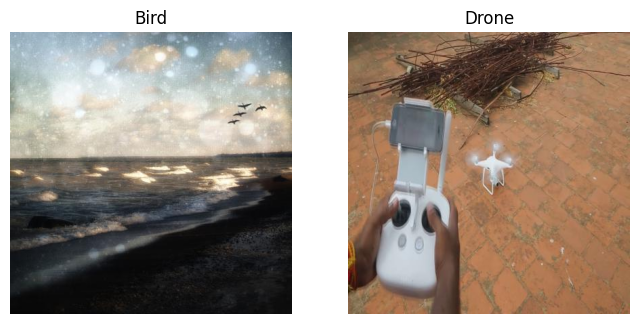

In [11]:
bird_path = os.path.join(train_dir, "bird")
drone_path = os.path.join(train_dir, "drone")

bird_img = os.listdir(bird_path)[0]
drone_img = os.listdir(drone_path)[0]

bird = Image.open(os.path.join(bird_path, bird_img))
drone = Image.open(os.path.join(drone_path, drone_img))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(bird)
plt.title("Bird")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(drone)
plt.title("Drone")
plt.axis("off")

plt.show()

In [12]:
# Step:6 Cehck Image Size

In [13]:
print("Bird image size:", bird.size)
print("Drone image size:", drone.size)

Bird image size: (416, 416)
Drone image size: (416, 416)


In [14]:
# Step:7 Create Image Dataset For Training

In [15]:
import tensorflow as tf
from tensorflow import keras

In [16]:
img_size = (224,224)
batch_size = 32

In [17]:
# Step:8 Load Training Dataset

In [18]:
img_size = (224, 224)
batch_size = 32

In [19]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary"
)

Found 2662 files belonging to 2 classes.


In [20]:
#Step:9 Load Valiation Dataset

In [21]:
val_dataset = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary"
)

Found 442 files belonging to 2 classes.


In [22]:
# Step:10 Load Test Dataset

In [23]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary"
)

Found 215 files belonging to 2 classes.


In [24]:
# Step:11 Check Class Names

In [25]:
import tensorflow as tf

img_size = (224,224)
batch_size = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary"
)

Found 2662 files belonging to 2 classes.


In [26]:
class_names = train_dataset.class_names
print("Classes:", class_names)

Classes: ['bird', 'drone']


In [27]:
# Step:12 Display Images From Dataset

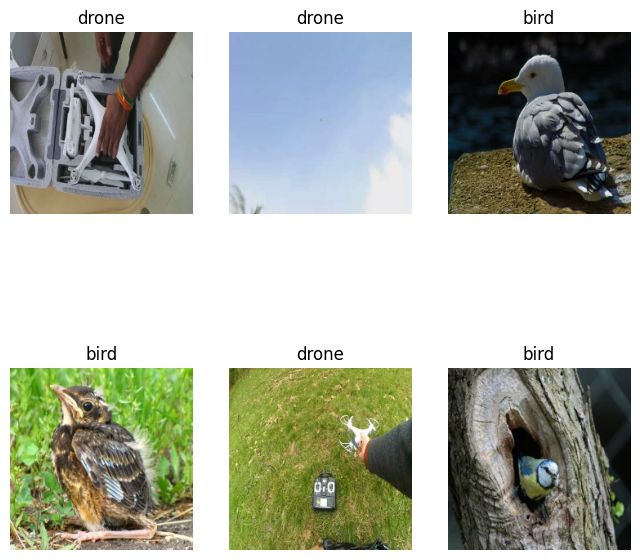

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

for images, labels in train_dataset.take(1):
    for i in range(6):
        ax = plt.subplot(2,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

In [29]:
# Step:13 Normalize These Images

In [30]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x,y: (normalization_layer(x),y))
val_dataset = val_dataset.map(lambda x,y: (normalization_layer(x),y))
test_dataset = test_dataset.map(lambda x,y: (normalization_layer(x),y))

In [31]:
train_dataset

<_MapDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

In [32]:
test_dataset

<_MapDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

In [33]:
val_dataset

<_MapDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>

In [34]:
# Step:14 Build CNN Model

In [35]:
from tensorflow.keras import layers
from tensorflow.keras import models

model = models.Sequential([
    
layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
layers.MaxPooling2D(2,2),

layers.Conv2D(64,(3,3),activation='relu'),
layers.MaxPooling2D(2,2),

layers.Conv2D(128,(3,3),activation='relu'),
layers.MaxPooling2D(2,2),

layers.Flatten(),

layers.Dense(128,activation='relu'),
layers.Dropout(0.5),

layers.Dense(1,activation='sigmoid')
])

C:\Users\User\anaconda3\envs\aerial_ai\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
# Step:15 Compile Model


In [37]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [38]:
# Model Summary

In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Step:16 Now we train model using the dataset

In [41]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.6082 - loss: 0.7432 - val_accuracy: 0.7195 - val_loss: 0.5586
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.7254 - loss: 0.5417 - val_accuracy: 0.7692 - val_loss: 0.4767
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.7911 - loss: 0.4504 - val_accuracy: 0.7738 - val_loss: 0.4569
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.8110 - loss: 0.4082 - val_accuracy: 0.7579 - val_loss: 0.5217
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.8212 - loss: 0.3810 - val_accuracy: 0.7851 - val_loss: 0.5460
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.8434 - loss: 0.3382 - val_accuracy: 0.8213 - val_loss: 0.4500
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.8727 - loss: 0.2885 - val_accuracy: 0.7919 - val_loss: 0.4312
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.8922 - loss: 0.2486 - val_accuracy: 0.8348 - v

In [42]:
#Step:17 Model Evaluation

In [43]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Accuracy:", test_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 258ms/step - accuracy: 0.8698 - loss: 0.4332
Test Accuracy: 0.869767427444458


In [44]:
# Step:18 Plotting Training Graphs

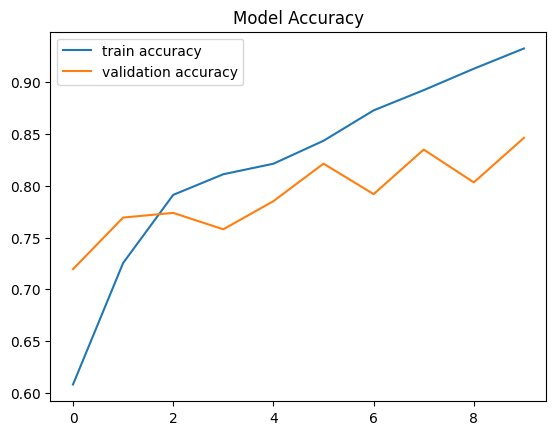

In [45]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

In [46]:
#Step:19 Save Model

In [47]:
model.save("bird_drone_classifier.h5")

In [48]:
#Step:20 Make Predictions

In [49]:
import os
import numpy as np
from PIL import Image

folder = r"C:\Aerial_dataset\Classification_dataset\test\bird"

image_name = os.listdir(folder)[0]

img_path = os.path.join(folder, image_name)

img = Image.open(img_path)
img = img.resize((224,224))

img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction: Drone")
else:
    print("Prediction: Bird")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step
Prediction: Bird


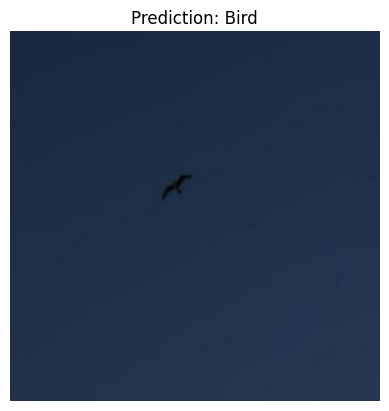

In [50]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title("Prediction: Bird")
plt.axis("off")
plt.show()

In [56]:
# Save the trained model

In [51]:
model.save("bird_drone_cnn_model.h5")

In [52]:
# Step:21 Generate Classification Report

In [53]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_dataset:
    
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)
    
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
              precision    recall  f1-score   support

         0.0       0.89      0.88      0.88       121
         1.0       0.84      0.86      0.85        94

    accuracy                           0.87       215
   macro avg       0.87      0.87      0.87       215
weighted avg       0.87      0.87      0.87       215



In [56]:
#Step:22 Plot Training Graphs

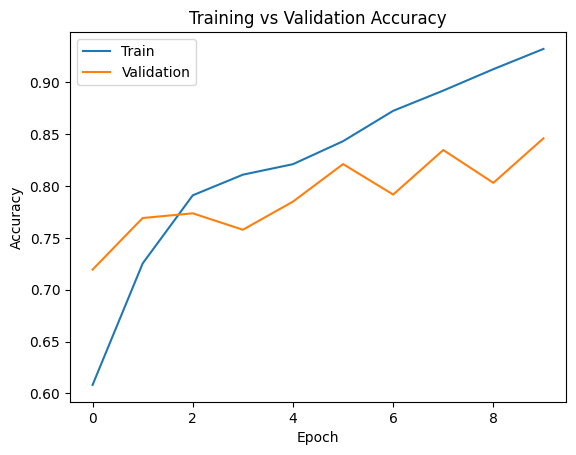

In [54]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

In [58]:
# Step:23 Transfer Learning Using Mobile Net V2

In [55]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

In [56]:
#Step:24 Load the pretrained Model

In [57]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [58]:
#Step:25 Freeze The Base Model So it doesnt change

In [59]:
base_model.trainable = False

In [60]:
base_model

<Functional name=mobilenetv2_1.00_224, built=True>

In [61]:
#Step:26 Build Transfer Learning Model

In [62]:
model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [63]:
model_tl

<Sequential name=sequential_1, built=True>

In [64]:
#Step:27 Complile Model

In [65]:
model_tl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [66]:
#Step:28 Train Model

In [67]:
history_tl = model_tl.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5
)

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 86s 892ms/step - accuracy: 0.9290 - loss: 0.1808 - val_accuracy: 0.9570 - val_loss: 0.0931
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 73s 871ms/step - accuracy: 0.9763 - loss: 0.0659 - val_accuracy: 0.9683 - val_loss: 0.0685
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 74s 872ms/step - accuracy: 0.9876 - loss: 0.0411 - val_accuracy: 0.9683 - val_loss: 0.0737
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 74s 873ms/step - accuracy: 0.9917 - loss: 0.0224 - val_accuracy: 0.9729 - val_loss: 0.0695
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 74s 874ms/step - accuracy: 0.9944 - loss: 0.0204 - val_accuracy: 0.9774 - val_loss: 0.0665


In [71]:
# Step:29 Evaluate Model

In [68]:
test_loss, test_accuracy = model_tl.evaluate(test_dataset)

print("Transfer Learning Test Accuracy:", test_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 727ms/step - accuracy: 0.9674 - loss: 0.1082
Transfer Learning Test Accuracy: 0.9674418568611145


In [73]:
# Step:30 Model Comparison

In [69]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model_tl.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 789ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 853ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 848ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 794ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97       121
         1.0       0.97      0.96      0.96        94

    accuracy                           0.97       215
   macro avg       0.97      0.97      0.97       215
weighted avg       0.97      0.97      0.97       215



In [75]:
#Step:31 Confusion Matrix


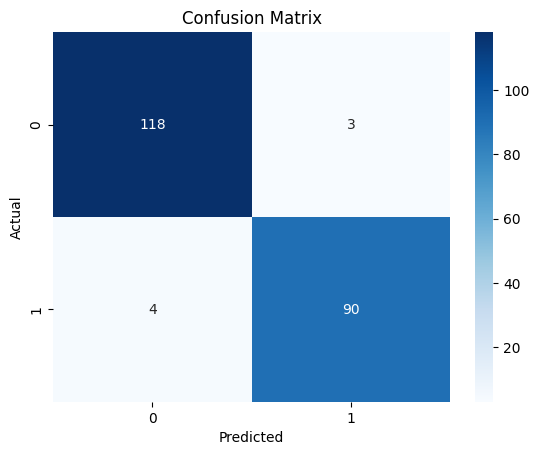

In [70]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Step:32 EDA(Training loss vs Validation Loss Graph)

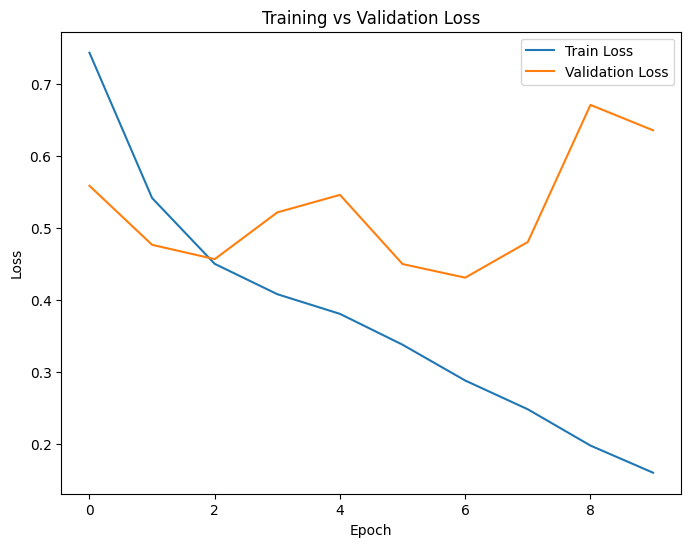

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
# Transfer Learning Accuracy Graph

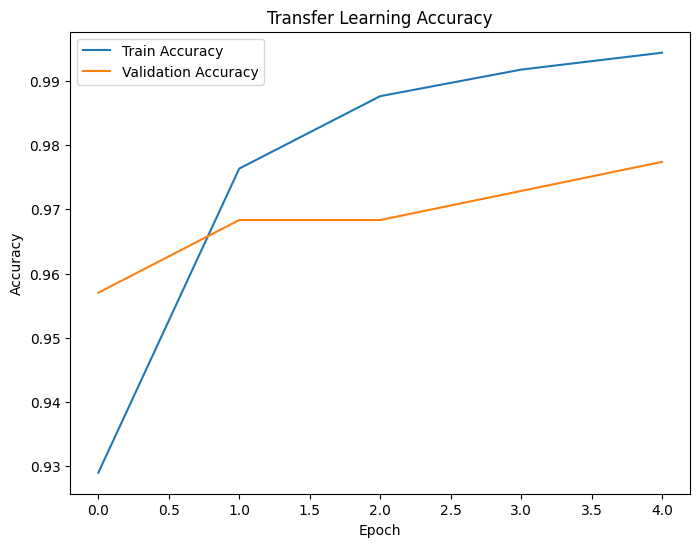

In [72]:
plt.figure(figsize=(8,6))

plt.plot(history_tl.history['accuracy'], label='Train Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy')

plt.title("Transfer Learning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [ ]:
# Training VS Validation Accuracy

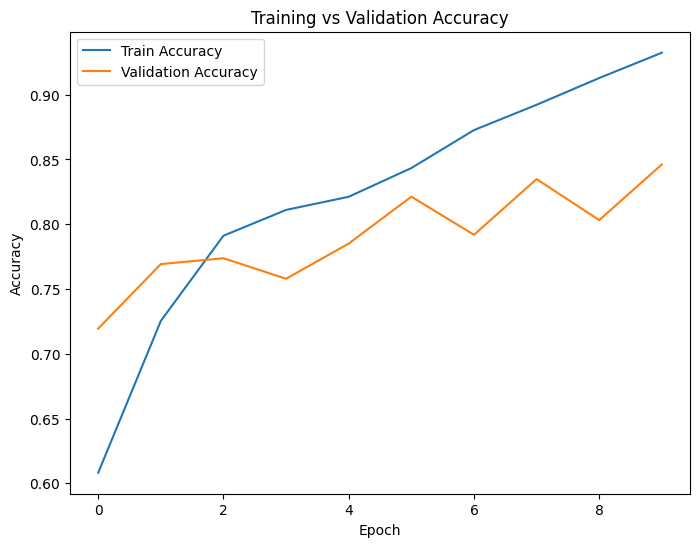

In [73]:
plt.figure(figsize=(8,6))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [ ]:
#ModelComparison Chart

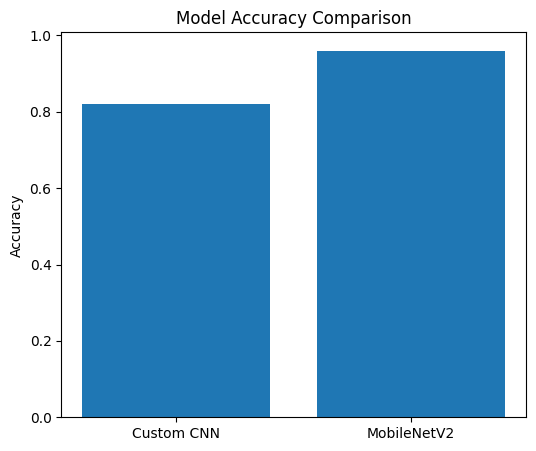

In [74]:
models = ['Custom CNN', 'MobileNetV2']
accuracy = [0.82, 0.96]

plt.figure(figsize=(6,5))
plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [ ]:
# Conclusion

In [ ]:
# Model Comparison Conclusion

#The custom CNN model achieved an accuracy of around 82% on the test dataset.
The transfer learning model using MobileNetV2 achieved approximately 96% accuracy.

#This improvement occurs because MobileNetV2 is pretrained on the ImageNet dataset
and can extract more robust visual features compared to a CNN trained from scratch.